# Experiment 1 – Support Vector Machine (SVM, with RBF)

## Mục tiêu
Trong notebook này, ta huấn luyện **Support Vector Machine (SVM, with RBF)** trên bộ dữ liệu Titanic, 
với **các đặc trưng cơ bản (Exp1)**:
- Không sử dụng Feature Engineering nâng cao
- Chỉ bao gồm: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`

Ta sẽ:
1. Thực hiện tiền xử lý dữ liệu
2. Khám phá dữ liệu (EDA cơ bản)
3. Huấn luyện Support Vector Machine (SVM, with RBF)
4. Đánh giá mô hình và xuất kết quả


### 1. Khám phá dữ liệu 

In [14]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
sns.set(style="whitegrid")

train = pd.read_csv('/kaggle/input/titanicdatasets/train (1).csv')
test = pd.read_csv('/kaggle/input/titanicdatasets/test (1).csv')

print(train.shape, test.shape)
train.head()


(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Biểu đồ phân bố biến đầu vào và biến đầu ra


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


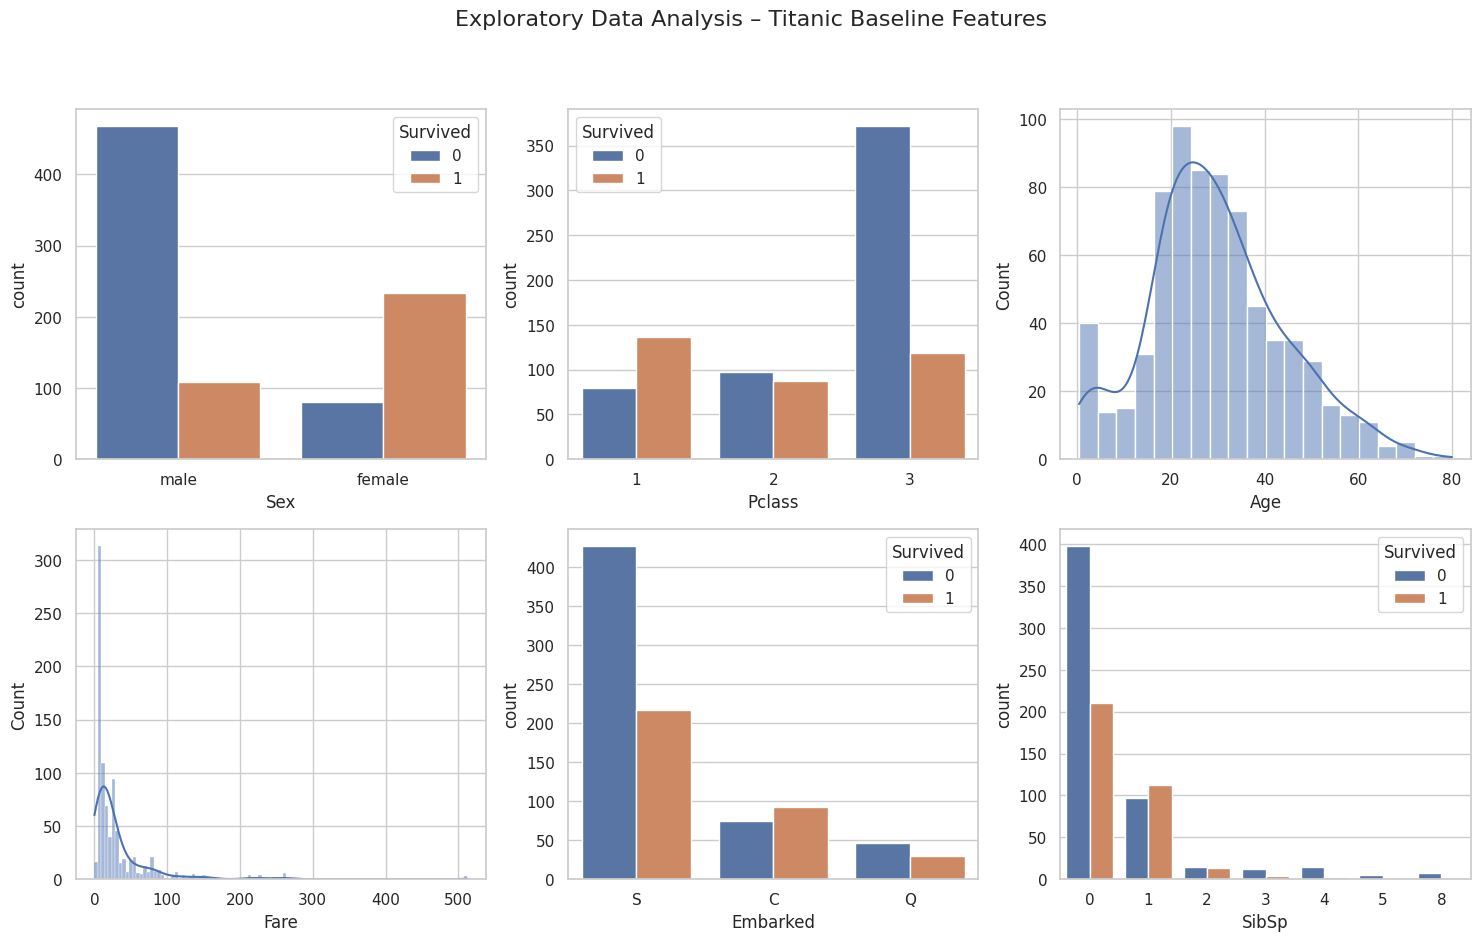

In [15]:
fig, axs = plt.subplots(2, 3, figsize=(18,10))
sns.countplot(x='Sex', hue='Survived', data=train, ax=axs[0,0])
sns.countplot(x='Pclass', hue='Survived', data=train, ax=axs[0,1])
sns.histplot(train['Age'], kde=True, ax=axs[0,2])
sns.histplot(train['Fare'], kde=True, ax=axs[1,0])
sns.countplot(x='Embarked', hue='Survived', data=train, ax=axs[1,1])
sns.countplot(x='SibSp', hue='Survived', data=train, ax=axs[1,2])
plt.suptitle("Exploratory Data Analysis – Titanic Baseline Features", fontsize=16)
plt.show()

### 3. Tiền xử lý dữ liệu

In [16]:
def preprocess_baseline(df):
    df['Sex'] = df['Sex'].map({'male':0, 'female':1})
    df['Embarked'] = df['Embarked'].fillna('S')
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    return df

train_clean = preprocess_baseline(train.copy())
test_clean = preprocess_baseline(test.copy())

X = train_clean[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 
                 'Embarked_Q', 'Embarked_S']]
y = train_clean['Survived']
X_test = test_clean[X.columns]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 4. Huấn luyện mô hình & đánh giá

In [17]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [18]:
model_name = "Support Vector Machine"

svm = SVC(kernel='rbf', random_state=42, probability=True) 
svm.fit(X, y)

cv_acc = cross_val_score(svm, X, y, cv=5, scoring='accuracy').mean()

print(f"{model_name} CV Accuracy: {cv_acc:.4f}")

Support Vector Machine CV Accuracy: 0.6724


### 5. Đánh giá trực quan 

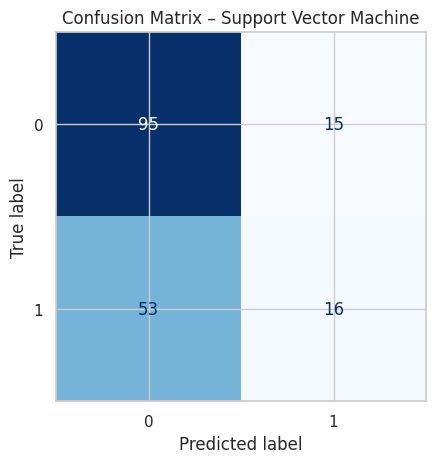

🔍 Classification Report – Support Vector Machine

              precision    recall  f1-score   support

           0     0.6419    0.8636    0.7364       110
           1     0.5161    0.2319    0.3200        69

    accuracy                         0.6201       179
   macro avg     0.5790    0.5478    0.5282       179
weighted avg     0.5934    0.6201    0.5759       179



In [19]:
# 1. Huấn luyện lại trên tập Training và Dự đoán trên tập Validation
svm.fit(X_train, y_train)
y_pred_val = svm.predict(X_val)

# 2. Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False) # colorbar=False giúp plot giống với format gốc
plt.title(f"Confusion Matrix – {model_name}")
plt.show()

# 3. Classification Report
print(f"🔍 Classification Report – {model_name}\n")
print(classification_report(y_val, y_pred_val, digits=4))

### 6. Xuất submission và log kết quả

In [22]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

model_name = "SVM_RBF" 
public_score = 0.66267 

svc = SVC(kernel='rbf', random_state=42, probability=True)
svc.fit(X, y)

cv_acc = cross_val_score(svc, X, y, cv=5, scoring='accuracy').mean()
cv_roc = cross_val_score(svc, X, y, cv=5, scoring='roc_auc').mean()

# --- Hiển thị kết quả in ra (Stdout) ---
print(f"CV Accuracy: {cv_acc:.4f}")
print(f"CV ROC-AUC: {cv_roc:.4f}")

# === Xuất file submission ===
y_pred = svc.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test_clean['PassengerId'],
    'Survived': y_pred.astype(int)
})
file_path = f'/kaggle/working/exp1_{model_name.lower()}_submission.csv'
submission.to_csv(file_path, index=False)
print(f"Saved submission: {file_path}")

!cp $file_path /kaggle/working/submission.csv


# === Ghi log kết quả và hiển thị bảng (DataFrame Output) ===
results_path = '/kaggle/working/exp1_results.csv'
header = "Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score\n"

# Kiểm tra và tạo header nếu file chưa tồn tại
if not os.path.exists(results_path):
    with open(results_path, 'w') as f:
        f.write(header)

experiment_name = "Exp1"

# Ghi kết quả vào file log
with open(results_path, 'a') as f:
    # Ghi kết quả của SVM vào log file
    f.write(f"{experiment_name},{model_name},{X.shape[1]},{cv_acc:.4f},{cv_roc:.4f},{public_score}\n")

# Tải lại DataFrame để hiển thị kết quả
results_df = pd.read_csv(results_path)
display(results_df)

CV Accuracy: 0.6724
CV ROC-AUC: 0.7380
Saved submission: /kaggle/working/exp1_svm_rbf_submission.csv


,Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score
0,Exp1,SVM_RBF,8,0.6724,0.738,0.66267


## Kết luận

### Mô hình: Support Vector Machine (SVM, RBF Kernel)

#### Tập dữ liệu: 
Chỉ sử dụng các đặc trưng gốc (Pclass, Sex, Age, SibSp, Parch, Fare, Embarked)

Không sử dụng: Name, Cabin, Ticket, Deck, Title, FamilySize

#### Kỹ thuật xử lý:

Điền giá trị thiếu (Age, Fare, Embarked)

Mã hóa biến phân loại bằng One-Hot Encoding (cho Embarked) và Label Encoding (cho Sex)

Chia train/test theo cấu trúc competition

#### Kết quả đánh giá:

Accuracy (cross-validation): 0.6724.

Public Kaggle Score: 0.66267

#### Nhận xét:

Mô hình SVM với kernel RBF hoạt động ở mức khởi đầu thấp trên tập baseline này, với CV Accuracy chỉ đạt 0.6724. Mặc dù chỉ số ROC-AUC (0.7380) cho thấy khả năng phân biệt tương đối tốt, hiệu suất tổng thể (Accuracy) vẫn còn yếu.

Tương tự như KNN, hiệu suất thấp của SVM RBF trên dữ liệu thô (chưa được xử lý) thường là do:

- Tính nhạy cảm với thang đo: SVM dựa trên khoảng cách giữa các điểm dữ liệu. Việc các đặc trưng như Fare có thang đo lớn hơn nhiều so với Pclass hoặc Sex làm sai lệch mặt phẳng phân tách.

- Thiếu tính tuyến tính: Việc cố gắng tìm một mặt phẳng phân tách phi tuyến tính trên tập đặc trưng cơ bản này không mang lại lợi ích đáng kể.

Dự kiến ở Exp2, bước chuẩn hóa dữ liệu số (Feature Scaling/Normalization) sẽ là yếu tố then chốt giúp SVM RBF cải thiện mạnh mẽ hiệu suất, vì nó giúp SVM tìm ra ranh giới phân lớp hiệu quả hơn. Bên cạnh đó, việc thêm các đặc trưng mới (Feature Engineering) cũng sẽ rất cần thiết.